In [1]:
#Importing required libraries for data handling,numerical computation, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the raw Uber ride dataset from CSV into pandas
df=pd.read_csv('uber.csv')
#Previewing the first 5 rows to understand the structure
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
#Checking the overall size of the dataset(rows,columns)
df.shape

(200000, 9)

In [4]:
#Detecting Null Values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [5]:
#Detecting Duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#Removing Null Values
df=df.dropna()

In [7]:
#Converting the pickup_datetime column from from plain text into a proper datetime object
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [8]:
#Feature Engeering:extracting individual time components from the pickup timestamp
df['Year']=df['pickup_datetime'].dt.year
df['Month']=df['pickup_datetime'].dt.month
df['Day']=df['pickup_datetime'].dt.day
df['Hour']=df['pickup_datetime'].dt.hour
df['Weekday']=df['pickup_datetime'].dt.weekday

In [9]:
#Check the new columns which were added correctly
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Weekday
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3


In [10]:
#Calculating the trip distance using the Haversine formula
def haversine(latitude1,longitude1,longitude2,latitude2):
     latitude1,longitude1,longitude2,latitude2=map(np.radians,[latitude1,longitude1,longitude2,latitude2])
     dilongitude=longitude2-longitude1
     dilatitude=latitude2-latitude1
     a=np.sin(dilatitude/2)**2+np.cos(latitude1)*np.cos(latitude2)*np.sin(dilongitude/2)**2
     b=2*np.arcsin(np.sqrt(a))
     km=6371*b
     return km
df['distance_km']=haversine(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_longitude'],df['dropoff_latitude'])

In [11]:
#Sanity-checking the new distance feature against fare_amount:
df[['fare_amount','distance_km']].head()

,fare_amount,distance_km
0,7.5,1.683323
1,7.7,2.457590
2,12.9,5.036377
3,5.3,1.661683
4,16.0,4.475450


In [12]:
#Reviewing the summary statistics of the newly computed distance feature
df['distance_km'].describe()

count    199999.000000
mean         20.855350
std         382.964642
min           0.000000
25%           1.215222
50%           2.120992
75%           3.875169
max       16409.239135
Name: distance_km, dtype: float64

In [13]:
#Data cleaning:removing rows with physically impossible values
df=df[(df['fare_amount']>0) & (df['fare_amount']<=120)]
df=df[df['pickup_latitude'].between(37,43) & df['dropoff_latitude'].between(37,43)]
df=df[df['pickup_longitude'].between(-81,-70) & df['dropoff_longitude'].between(-81,-70)]
df=df[df['passenger_count'].between(1,6)]
df=df[df['distance_km'].between(0.01,100)]

print('Fares<=0:',(df['fare_amount']<=0).sum())
print('Fares>120:',(df['fare_amount']>120).sum())
print('Distance>100km:',(df['distance_km']>100).sum())
print('Passenger count more than 1 to 6:',(~df['passenger_count'].between(1,6)).sum())


Fares<=0: 0
Fares>120: 0
Distance>100km: 0
Passenger count more than 1 to 6: 0


In [14]:
#Reviewing statistics post-cleaning to confirm the dataset is now free of the invalid values
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Weekday,distance_km
count,1.925690e+05,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000,192569.000000
mean,2.771020e+07,11.299100,-73.975597,40.750858,-73.974625,40.751148,1.690090,2011.746766,6.282652,15.699801,13.490941,3.049863,3.366390
std,1.600759e+07,9.368381,0.036631,0.028880,0.036466,0.032490,1.305421,1.862893,3.440847,8.687347,6.515481,1.946595,3.705705
min,1.000000e+00,0.010000,-75.387785,39.605438,-75.417737,39.607967,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.010016
25%,1.382808e+07,6.000000,-73.992281,40.736500,-73.991600,40.735382,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,1.286453
50%,2.774892e+07,8.500000,-73.982142,40.753318,-73.980587,40.753767,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,2.185455
75%,4.153738e+07,12.500000,-73.968538,40.767553,-73.965627,40.768333,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,3.945824
max,5.542357e+07,119.000000,-71.896038,42.478467,-71.836652,42.464187,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,99.162509


In [15]:
#Add holiday, time-of-day, weekend, and rush-hour features
def is_holiday_sample(date):
    month_day=(date.month,date.day)
    fixed_holidays=[(1,1),(7,4),(12,25),(12,31),(11,11)]
    return 1 if month_day in fixed_holidays else 0
df['is_holiday']=df['pickup_datetime'].apply(is_holiday_sample)

def get_time_of_day(hour):
    if 5<= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour <21:
        return 'Evening'
    else:
        return 'Night'
df['time_of_day'] = df['Hour'].apply(get_time_of_day)

df['is_weekend'] = df['Weekday'].isin([5,6]).astype(int)
df['is_rush_hour'] = df['Hour'].isin([7,8,9,16,17,18,19]).astype(int)
#Check the new columns
df[['is_holiday','time_of_day','is_weekend','is_rush_hour']].head()

,is_holiday,time_of_day,is_weekend,is_rush_hour
0,0,Evening,0,1
1,0,Evening,0,0
2,0,Night,0,0
3,0,Morning,0,1
4,0,Evening,0,1


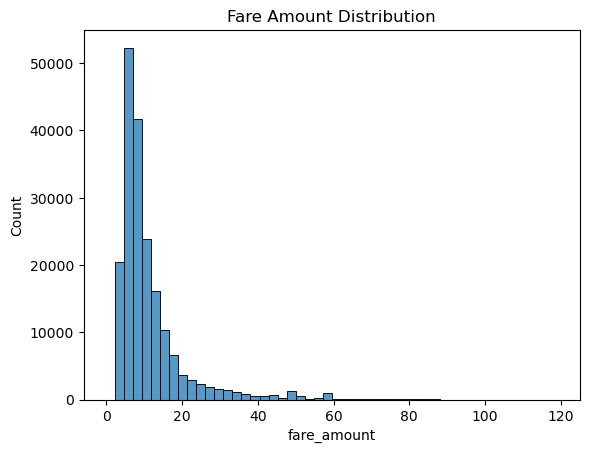

Fare skewness: 3.082515822623912


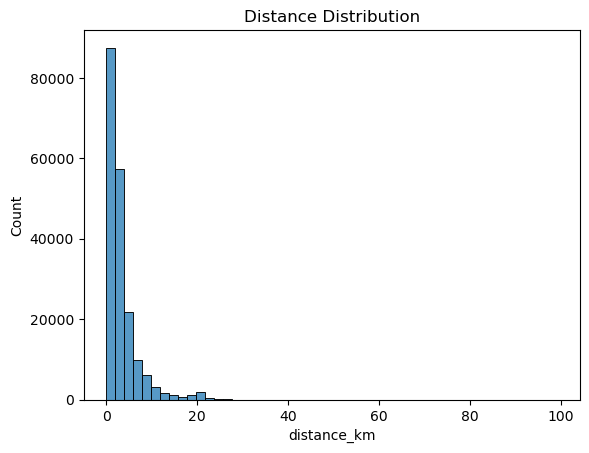

Distance skewness: 4.258861051706464


In [16]:
#Exploitary Data analysis(EDA)
#1.Univarente Analysis
plt.figure()
sns.histplot(df['fare_amount'],bins=50)
plt.title('Fare Amount Distribution')
plt.show()
print('Fare skewness:',df['fare_amount'].skew())

plt.figure()
sns.histplot(df['distance_km'],bins=50)
plt.title('Distance Distribution')
plt.show()
print('Distance skewness:',df['distance_km'].skew())

<Axes: xlabel='distance_km', ylabel='fare_amount'>

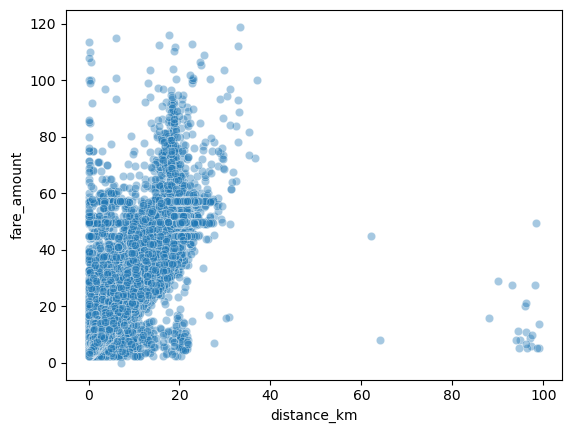

In [17]:
#2.Bivarente Analysis
sns.scatterplot(data=df,x='distance_km',y='fare_amount',alpha=0.4)

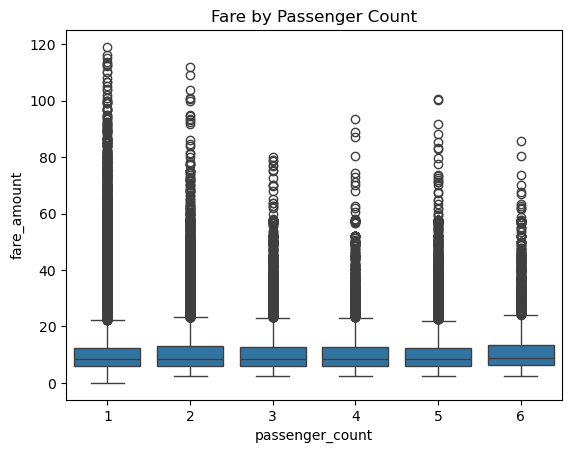

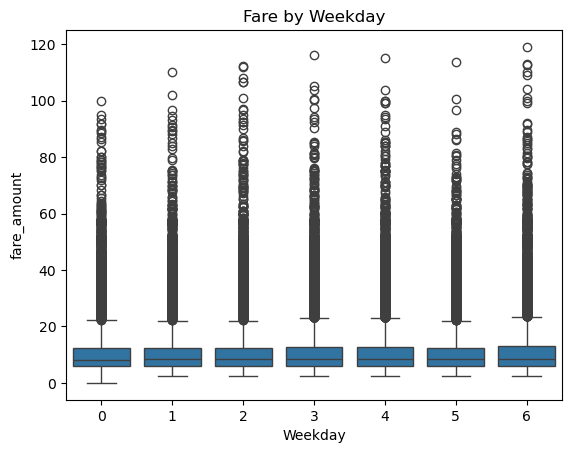

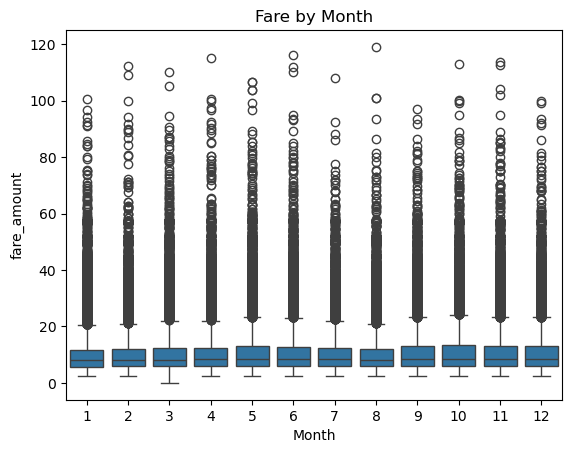

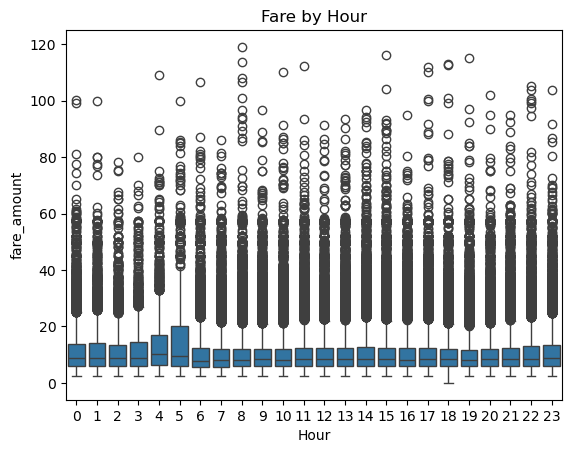

In [18]:
#Bivarente Analysis(Numerical vs Categorical)
plt.figure()
sns.boxplot(data=df,x='passenger_count',y='fare_amount')
plt.title('Fare by Passenger Count')
plt.show()

plt.figure()
sns.boxplot(data=df,x='Weekday',y='fare_amount')
plt.title('Fare by Weekday')
plt.show()

plt.figure()
sns.boxplot(data=df,x='Month',y='fare_amount')
plt.title('Fare by Month')
plt.show()

plt.figure()
sns.boxplot(data=df,x='Hour',y='fare_amount')
plt.title('Fare by Hour')
plt.show()


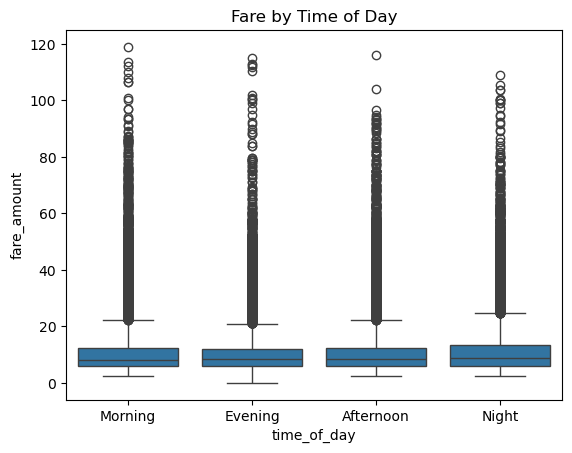

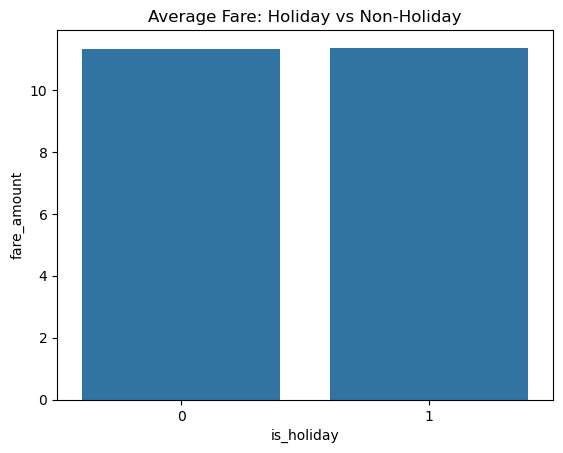

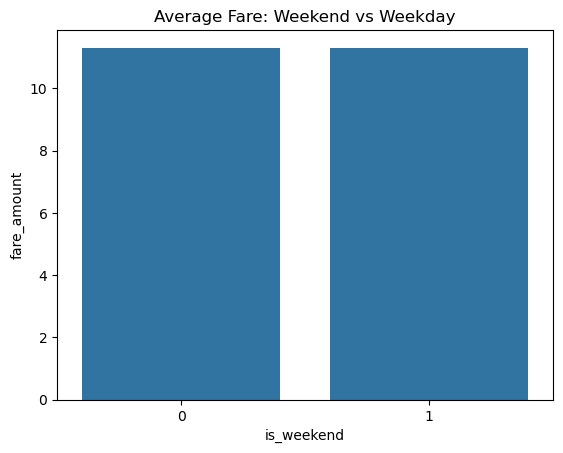

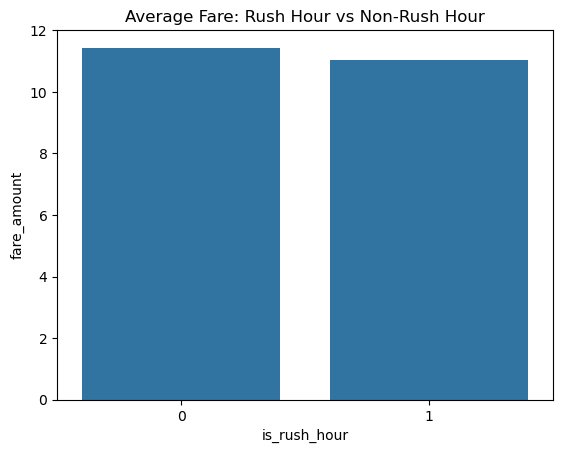

is_holiday
0    11.298487
1    11.359092
Name: fare_amount, dtype: float64
is_weekend
0    11.307302
1    11.278400
Name: fare_amount, dtype: float64
is_rush_hour
0    11.441655
1    11.024635
Name: fare_amount, dtype: float64


In [19]:
#Bivarenete analysis for new features
plt.figure()
sns.boxplot(data=df,x='time_of_day',y='fare_amount',order=['Morning','Evening','Afternoon','Evening','Night'])
plt.title('Fare by Time of Day')
plt.show()

plt.figure()
sns.barplot(data=df,x='is_holiday',y='fare_amount',errorbar=None)
plt.title('Average Fare: Holiday vs Non-Holiday')
plt.show()

plt.figure()
sns.barplot(data=df,x='is_weekend',y='fare_amount',errorbar=None)
plt.title('Average Fare: Weekend vs Weekday')
plt.show()

plt.figure()
sns.barplot(data=df,x='is_rush_hour',y='fare_amount',errorbar=None)
plt.title('Average Fare: Rush Hour vs Non-Rush Hour')
plt.show()

#Print the actual numbers behind each chart
print(df.groupby('is_holiday')['fare_amount'].mean())
print(df.groupby('is_weekend')['fare_amount'].mean())
print(df.groupby('is_rush_hour')['fare_amount'].mean())

In [20]:
#Convert the text category time_of_day into seperate 0/1 columns the model can use 
df_encoded=pd.get_dummies(df,columns=['time_of_day'],drop_first=True)
df_encoded.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'Year', 'Month', 'Day', 'Hour',
       'Weekday', 'distance_km', 'is_holiday', 'is_weekend', 'is_rush_hour',
       'time_of_day_Evening', 'time_of_day_Morning', 'time_of_day_Night'],
      dtype='object')

In [21]:
#Model Preparation:defining the feature set (inputs) and target variable(output) for the model
data=['Hour','Weekday','Month','Year','passenger_count','distance_km','is_holiday','is_weekend','is_rush_hour','time_of_day_Morning','time_of_day_Night']
x=df_encoded[data]
y=df_encoded['fare_amount']

In [22]:
#Splitting the dataset:dividing data into training and testing sets to allow honest evaluation
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print('x_train shape:',x_train.shape)
print('x_test shape:',x_test.shape)
print('y_train shape:',y_train.shape)
print('y_test shape:',y_test.shape)

x_train shape: (154055, 11)
x_test shape: (38514, 11)
y_train shape: (154055,)
y_test shape: (38514,)


In [23]:
#Verifying the training feature set looks correct before proceeding to scaling and modeling
x_train.head()

,Hour,Weekday,Month,Year,passenger_count,distance_km,is_holiday,is_weekend,is_rush_hour,time_of_day_Morning,time_of_day_Night
13915,8,2,3,2009,1,1.004111,0,0,1,True,False
188003,7,2,11,2014,3,21.382387,0,0,1,True,False
180811,21,1,2,2013,2,2.485305,0,0,0,False,True
179202,12,0,7,2014,1,9.167442,0,0,0,False,False
174008,16,4,11,2012,1,0.522223,0,0,1,False,False


In [24]:
#Data scaling:standardizing feature values so no single feature dominates the model's training process due to differences in raw units
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

fare_amount            1.000000
distance_km            0.865300
Year                   0.123999
Month                  0.024558
passenger_count        0.013993
time_of_day_Night      0.007444
Weekday                0.004838
is_holiday             0.000648
time_of_day_Morning   -0.001127
is_weekend            -0.001391
Hour                  -0.020101
is_rush_hour          -0.021114
Name: fare_amount, dtype: float64


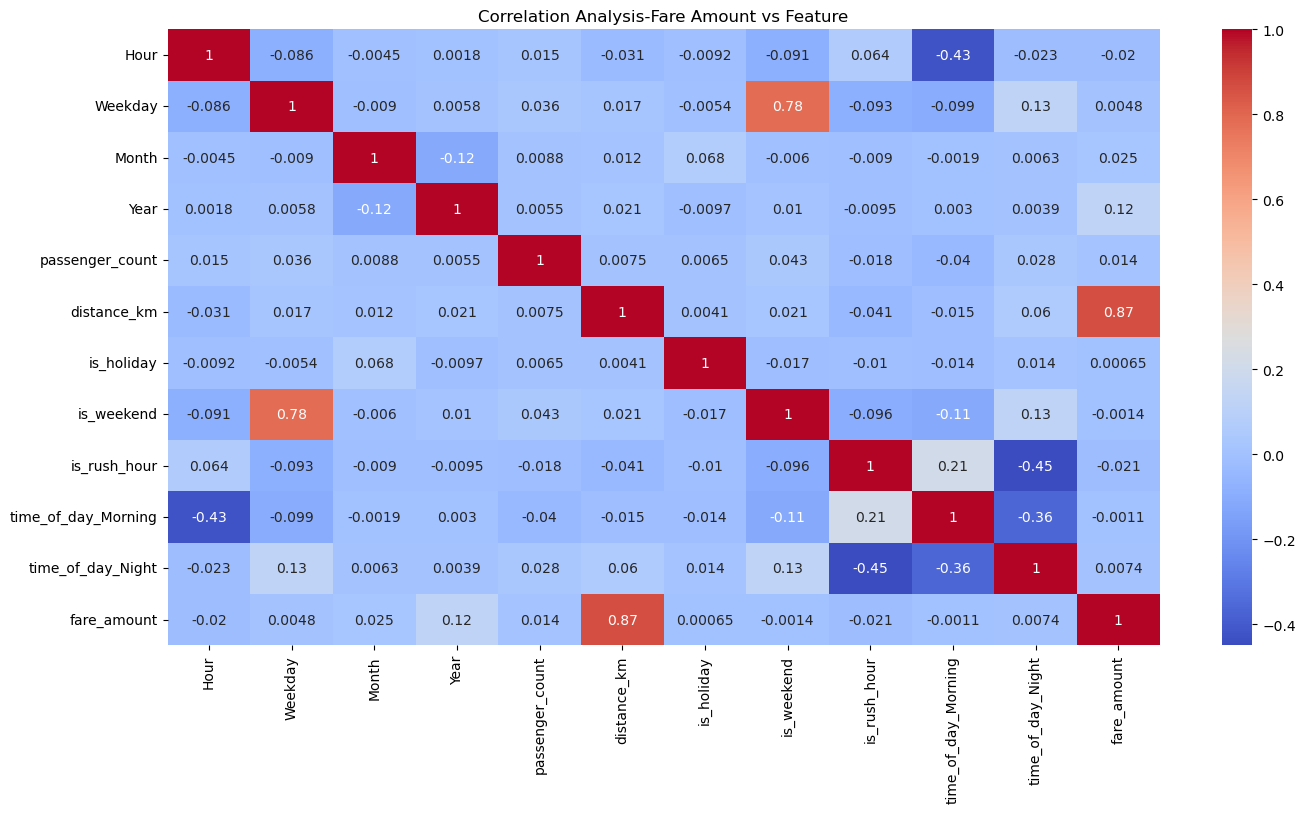

In [25]:
#Correlation analysis:quantifying the linear relationship,as well as between features themselves,to support feature selection decisions with data rather than assumption alone
col=data+['fare_amount']
correlation=df_encoded[col].corr()
print(correlation['fare_amount'].sort_values(ascending=False))
plt.figure(figsize=(16,8))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation Analysis-Fare Amount vs Feature')
plt.show()

In [26]:
#Pick two models to compare:Linear regression and Random forest
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
#Train Linear regression on the scaled data
lr_model=LinearRegression()
lr_model.fit(x_train_scaled,y_train)
#Train Random Forest on unscaled data(trees dont need scaling
rf_model=RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1)
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
#Check how accurate each model's predictions are
from sklearn.metrics import *

def eval_model(name,ytest,ypred):
    mae=mean_absolute_error(ytest,ypred)
    mse=mean_squared_error(y_test,ypred)
    rms=np.sqrt(mse)
    r2=r2_score(ytest,ypred)
    print('MAE',mae,'MSE',mse,'RMS',rms)
    print('R2',r2)
    
#Linear regression results
ypred_lr=lr_model.predict(x_test_scaled)
eval_model('Linear Regression',y_test,ypred_lr)

#Generate Scores to check overfitting/underfitting
print('----------------------------')
print('Train score:',lr_model.score(x_train_scaled,y_train))
print('Test score:',lr_model.score(x_test_scaled,y_test))

MAE 2.221406797435945 MSE 21.942866833136062 RMS 4.6843213844842095
R2 0.7459396129048622
----------------------------
Train score: 0.7673072699863541
Test score: 0.7459396129048622


In [28]:
#Random Forest results
ypred_rf=rf_model.predict(x_test)
eval_model('Random Forest',y_test,ypred_rf)

#Generate Scores to check overfitting/underfitting
print('----------------------------')
print('Train score:',rf_model.score(x_train,y_train))
print('Test score:',rf_model.score(x_test,y_test))

MAE 1.9693944219107857 MSE 14.395270216872694 RMS 3.794109937373019
R2 0.8333277072932457
----------------------------
Train score: 0.8673200960776721
Test score: 0.8333277072932457


## Evaluating and Fine-tuning the Regression Model

**Random Forest is the better model.** It makes smaller mistakes on average and explains more
of why fares differ from ride to ride.Linear Regression is simpler and easier to explain
(it just draws one straight line through the data),but real fares dont follow a perfectly
straight line - they're affected by combinations os factors, like distance changing differently
depending on the time of day. Random Forest can pick up on these combinations; Linear Regression
can't.

In [29]:
#Try differant settings to see if the model can do better(Tuning)
from sklearn.model_selection import GridSearchCV 
param_grid={'n_estimators':[100],'max_depth':[8,10,15,None],'min_samples_leaf':[1,5,10],'min_samples_split':[2,5]}
grid_search=GridSearchCV(
    estimator=RandomForestRegressor(random_state=42,n_jobs=1),
    param_grid=param_grid,cv=3,scoring='r2',n_jobs=-1)
grid_search.fit(x_train,y_train)

#Show which settings worked best
print('Best parameters:',grid_search.best_params_)
print('Best score:',grid_search.best_score_)

#Generate Scores to check overfittin/underfitting
best_rf_model=grid_search.best_estimator_
print('Train score:',best_rf_model.score(x_train,y_train))
print('Test score:',best_rf_model.score(x_test,y_test))

Best parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 0.8383932876478596
Train score: 0.8588185958074346
Test score: 0.8344387042849819


## Why is this the best model?
**We compares Linear Regression and Random Forest performed better on every
measure - lower average error (MAE) and a high R2 score, meaning it explains more of why
fares differ from ride to ride.**

**We then tried tuning Random Forest's settings to see if a differant 
combination could improve it further or reduce overfitting.
After testing multiple combinations with GridSearchCV,the 
tuned model's score came out essentially the same as the original 
settings**

**This tells the model has learned nearly everything it can from the current features
(distance,time,passenger_count,and the holiday/weekend/rush-hour flags).The remaining
prediction error likely comes from real-world factors not captured in this data.Random
Forest with the original settings (max_depth=10,n_estimators=100) is therefore
selected as the final model**